# Sparse Optimization for Differential-Equation Discovery
### A ~30-minute hands-on tour

**The problem.** Given noisy measurements of a dynamical system's state over time,
can we recover the *governing equations* automatically — as a short, interpretable
formula rather than a black-box model?

**The idea (sparse regression).** Stack a large library of candidate terms
$\Theta(X) = [\,1,\ x,\ y,\ x^2,\ xy,\ \dots\,]$ and look for a **sparse** coefficient
matrix $\Xi$ such that

$$\dot{X} \;\approx\; \Theta(X)\,\Xi .$$

Most candidate terms should be *off* (zero), leaving only the few that truly govern
the dynamics. Different methods differ in **how they estimate $\dot X$** and **what
kinds of terms** they allow.

## The four methods in this tutorial

| Notebook | Method | Key idea | Shines when |
|---|---|---|---|
| `01` | **Vanilla SINDy** | Sparse regression with numerically estimated derivatives. | Clean polynomial ODEs. |
| `02` | **Weak SINDy** | Integral / weak form — *no* pointwise derivatives. | High noise. |
| `03` | **SINDy-PI** | Implicit formulation for **rational** dynamics. | Rational / non-polynomial terms. |
| `04` | **SODAs** | Discover **algebraic constraints first**, then dynamics. | Differential–algebraic systems (DAEs). |

Notebook `05` pits them against each other on two benchmarks: a polynomial ODE
(noise-robustness head-to-head) and Michaelis–Menten enzyme kinetics (a DAE).

> **Packages:** `pysindy` (methods 1–3) and `DaeFinder` (SODAs, method 4).

In [1]:
# --- Environment setup (kept INACTIVE on purpose) -------------------------
# Uncomment the next line the first time you run these notebooks to install
# every dependency (pysindy, DaeFinder, cvxpy, ...). Left commented so the
# notebook never reinstalls packages while you teach from it.
# !pip install -r ../requirements.txt

In [2]:
import os, sys, warnings
warnings.filterwarnings("ignore")

# Make the shared tutorial package (src/sparse_demos) importable regardless of
# whether the notebook is launched from notebooks/ or the repo root.
def _add_src():
    here = os.getcwd()
    for base in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        cand = os.path.join(base, "src")
        if os.path.isdir(os.path.join(cand, "sparse_demos")):
            if cand not in sys.path:
                sys.path.insert(0, cand)
            return cand
    raise RuntimeError("Could not locate src/sparse_demos")
_add_src()

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# Sanity check: confirm the two engines import and report versions.
import pysindy as ps
import daeFinder
print("pysindy :", ps.__version__)
print("DaeFinder imported from:", os.path.dirname(daeFinder.__file__))

pysindy : 2.1.0
DaeFinder imported from: /Users/manu_jay/git_repos/SparseModelTutorials/.venv/lib/python3.11/site-packages/daeFinder


## A 60-second taste

Below: a Lotka–Volterra (predator–prey) trajectory and the polynomial candidate
library we will ask each method to prune down to the true two-term-per-equation model.

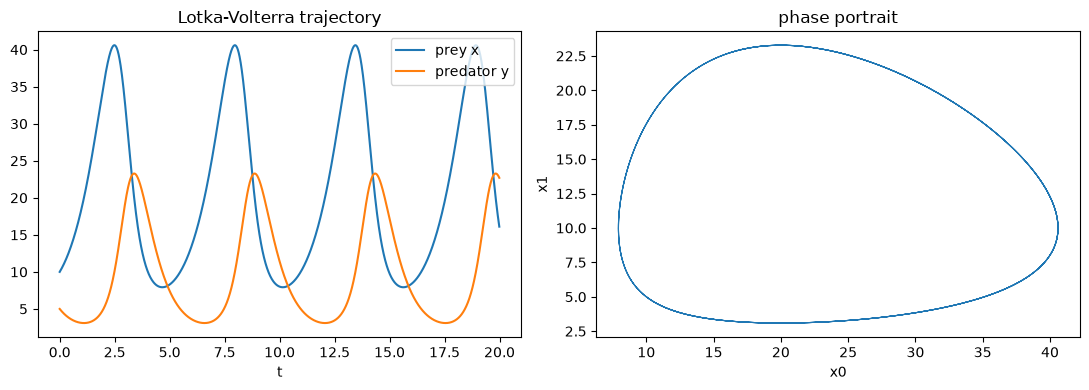

Candidate library terms (degree 2): ['1', 'x0', 'x1', 'x0 x0', 'x0 x1', 'x1 x1']
Library matrix shape: (2000, 6) -> SINDy seeks a SPARSE Xi for dX = Theta @ Xi


In [4]:
from sparse_demos import systems, libraries, plotting

t, X = systems.simulate("lotka_volterra", t_span=(0, 20), dt=0.01)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plotting.plot_trajectories(t, X, labels=["prey x", "predator y"],
                           title="Lotka-Volterra trajectory", ax=axes[0])
plotting.plot_phase(X, title="phase portrait", ax=axes[1])
plt.tight_layout(); plt.show()

Theta, names = libraries.polynomial_library(X, degree=2)
print("Candidate library terms (degree 2):", names)
print("Library matrix shape:", Theta.shape, "-> SINDy seeks a SPARSE Xi for dX = Theta @ Xi")

**Next:** open `01_sindy_intro.ipynb` to recover these equations with vanilla SINDy.